## 97. Validation Insitu
0. Packages
1. Settings
2. Read Data
3. Plot data

### 0. Packages

In [1]:
# Packages
import colormaps as cmaps
import glob
import geopandas as gpd
import colormaps as cmaps
import numpy as np
import os
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import xarray as xr
from shapely.geometry import box
from scipy import stats
from scipy.stats import gaussian_kde
from tqdm import tqdm

from resilientplotterclass import rpclass

### 1. Settings

In [8]:
# File paths gtsm
file_path_gtsm_combined_zarr = r'p:\1230882-emodnet_hrsm\GTSMv3.0EMODnet\CMEMS_intertidal_SDB\zarr_files\gtsm_model_his_combined_v2.zarr'
file_path_gtsm_stations_parquet = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\02_gtsm_files\gtsm_stations_v2.parquet'

# File paths gebco
file_path_gebco_tif = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\03_gebco_files\gebco_2024.tif'
file_path_gebco_hat_lat_tif = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\03_gebco_files\gebco_2024_hat_lat.tif'

# URLs to global lat/hat data (LAT/HAT wrt MSL based on gebco 2023)
file_path_global_lat_zarr = r'https://nx7384.your-storageshare.de/apps/sharingpath/wetwin/public/gebco2023/lat.zarr'
file_path_global_hat_zarr = r'https://nx7384.your-storageshare.de/apps/sharingpath/wetwin/public/gebco2023/hat.zarr'

# File paths feasibility map
file_path_fm_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result.parquet'
file_path_fm_ed_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result_erosion_dilation.parquet'

# File paths tiles
file_path_tiles_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\AOI_polygons_world\df_boxes_world_Z10_filtered_v2.parquet'

# File paths osm
file_path_osm_tifs = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\00_osm_files\water_rasters\*.tif')
file_path_osm_parquet = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\00_osm_files\geometries\osm_water_metadata.parquet'

# File paths sdbs
#file_path_sdbs_ = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_dynamics\04_clipped\*.tif')
#file_path_sdbs_ = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_50m_dynamics\05_reprojected\*.tif')
file_path_sdbs_ = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_10m_dynamics\04_clipped\*.tif')
file_path_sdbs_ = [file_path for file_path in file_path_sdbs_ if not file_path.endswith('.tif.aux.xml')]
names = list(set(os.path.basename(file_path).split('_t')[0] for file_path in file_path_sdbs_))
file_path_sdbs = {}
for name in names:
    file_path_sdbs[name] = [file_path for file_path in file_path_sdbs_ if name in os.path.basename(file_path)]

# File paths insitus
file_path_insitus = [
    r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\06_validation\Local\NL2018_v2.tif',
    r'p:\11209821-cmems-global-sdb\00_miscellaneous\Validation_data\GER_WaddenSea_BSHGeopoartal_WGS84_100m_LAT.tif',
    r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\06_validation\Local\MNT_ATL100m_HOMONIM_GEO_refNM_ZNEG.tif',
]

In [9]:
# Define guidelines
gls = {
    'general':
        {'crs': 'EPSG:4326',
         'cartopy_bounds': [3.5, 7, 51, 54],
         'cartopy_features': ['land', 'ocean', 'lakes', 'coastline', 'borders']},
    'geom_style':
        {'gtsm': {'color': 'blue', 'markersize': 10, 'label': 'GTSM stations'},
         'tiles': {'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.5, 'label': 'Tiles'},
         'feasibility_map': {'facecolor': 'blue', 'edgecolor': 'None', 'alpha': 0.25, 'linewidth': 1.5, 'label': 'Feasibility map'},
         'feasibility_map_ed': {'facecolor': 'red', 'edgecolor': 'None', 'alpha': 0.25, 'linewidth': 1.5, 'label': 'Feasibility map (erosion-dilation)'},
         'tiles nearest distance': {'column': 'nearest_station_distance', 'vmin': 0, 'vmax': 50, 'cmap': 'Greens_r', 'alpha': 0.5, 'legend': True, 'legend_kwds': {'label': 'Distance to nearest GTSM station [km]'}, 'append_axes_kwargs': {'position': 'right', 'size': 0.2, 'pad': 0.2}},
         'tiles intertidal coverage': {'column': 'intertidal_coverage', 'vmin': 0, 'vmax': 100, 'cmap': 'Greens', 'alpha': 0.5, 'legend': True, 'legend_kwds': {'label': 'Intertidal coverage [%]'}, 'append_axes_kwargs': {'position': 'right', 'size': 0.2, 'pad': 0.2}},
         'tiles filtered': {'facecolor': 'none', 'edgecolor': 'red', 'linewidth': 1.5, 'label': 'Filtered tiles'}},
    'extent_style':
        {'dutch waddenzee': {'xlim': [4.921875001948056, 5.976562501956762], 'ylim': [53.12040528463854, 53.540307393022395]},
    }
}

# Set guidelines
rpc = rpclass(gls)

# Get guidelines
gls = rpc.get_guidelines()

# Get bounds and crs
crs = gls['general']['crs']
bounds = gls['general']['cartopy_bounds']

# Show guidelines
rpc.show_guidelines(open=False)

In [10]:
# Read gtsm
ds_gtsm_combined = xr.open_zarr(file_path_gtsm_combined_zarr, consolidated=True)
gdf_gtsm_stations = gpd.read_parquet(file_path_gtsm_stations_parquet)

# Read gebco
ds_gebco = rxr.open_rasterio(file_path_gebco_tif, masked=True).squeeze()
ds_gebco_hat_lat = rxr.open_rasterio(file_path_gebco_hat_lat_tif, masked=True)

# Read global hat and lat data
da_global_hat = xr.open_zarr(file_path_global_hat_zarr)['hat_correction']
da_global_hat = da_global_hat.rename({'lat':'y', 'lon':'x'})
da_global_hat = da_global_hat.rio.write_crs('EPSG:4326')
da_global_lat = xr.open_zarr(file_path_global_lat_zarr)['lat_correction']
da_global_lat = da_global_lat.rename({'lat':'y', 'lon':'x'})
da_global_lat = da_global_lat.rio.write_crs('EPSG:4326')

# Combine along band dimension
da_global_hat_lat = xr.merge([da_global_hat, da_global_lat], compat='override').to_dataarray(dim='band')
ds_gebco_hat_lat = da_global_hat_lat

# Read feasibility map
gdf_fm = gpd.read_parquet(file_path_fm_parquet)
gdf_fm_ed = gpd.read_parquet(file_path_fm_ed_parquet)

# Read tiles
gdf_tiles = gpd.read_parquet(file_path_tiles_parquet)
gdf_tiles['nearest_station_distance'] = gdf_tiles['nearest_station_distance']/1000  # Convert to km
gdf_tiles['intertidal_coverage'] = gdf_tiles['intertidal_coverage']*100  # Convert to percentage
gdf_tiles['intertidal_coverage_ed'] = gdf_tiles['intertidal_coverage_ed']*100  # Convert to percentage
gdf_tiles['processed'] = (gdf_tiles['nearest_station_distance'] < 37) & (gdf_tiles['intertidal_coverage'] > 0) & (gdf_tiles['intertidal_coverage_ed'] > 1)
print('Number of tiles:', len(gdf_tiles))
print(gdf_tiles['processed'].value_counts())

# Add file path sdb to gdf_tiles
gdf_tiles['file_path_sdb'] = gdf_tiles['name'].apply(
    lambda x: file_path_sdbs.get(x, None)
)

# Read osm
gdf_osm = gpd.read_parquet(file_path_osm_parquet)

# Read insitus
ds_insitus = [rxr.open_rasterio(file_path, masked=True).squeeze() for file_path in file_path_insitus]
gdf_insitus = gpd.GeoDataFrame(data={'file_path': file_path_insitus, 'geometry': [box(*ds.rio.bounds()) for ds in ds_insitus]}, crs=crs)
del ds_insitus

Number of tiles: 38639
processed
False    27307
True     11332
Name: count, dtype: int64


In [11]:
def get_extents(gdf_tiles, tile_names=[], buffer=0):
    if tile_names is not None:
        gdf_tiles = gdf_tiles[gdf_tiles['name'].isin(tile_names)]
    
    # Buffer bounds
    bounds = [float(bound) for bound in gdf_tiles.total_bounds]
    bounds = [bounds[0] - buffer, bounds[1] - buffer, bounds[2] + buffer, bounds[3] + buffer]
    
    # Convert bounds to extent dictionary
    extent = {'xlim': [bounds[0], bounds[2]], 'ylim': [bounds[1], bounds[3]]}

    return extent

# Example usage of get_bounds function
extent_styles = {}
extent_styles['dutch waddenzee'] = get_extents(gdf_tiles, tile_names=['z10_x526_y332', 'z10_x528_y331'])
for key, value in extent_styles.items():
    print(f"'{key}': {value},")

'dutch waddenzee': {'xlim': [4.921875001948056, 5.976562501956762], 'ylim': [53.12040528463854, 53.540307393022395]},


In [12]:
def get_sdb_and_insitu_data(gdf_tiles, file_path_insitu, bounds, skip=1):
    # SDB data
    file_paths_ls = [file_paths for file_paths in gdf_tiles['file_path_sdb'].values if file_paths is not None]
    file_paths = [file_path for sublist in file_paths_ls for file_path in sublist]
    date_ranges = list(set(os.path.basename(file_path).split('_t')[1].split('.')[0] for file_path in file_paths))
    date_ranges.sort()
    print('Date ranges:', date_ranges)
    
    ds_sdb_dict = {}
    for date_range in date_ranges:
        file_paths_date_range = [file_path for file_path in file_paths if date_range in os.path.basename(file_path)]
        ds_sdb_ls = [rxr.open_rasterio(file_path, masked=True).squeeze() for file_path in file_paths_date_range]
        ds_sdb_ls = [ds.rio.set_nodata(np.nan) for ds in ds_sdb_ls]
        ds_sdb_ls = [ds.rio.reproject(dst_crs=crs, resolution=ds.rio.resolution()[0]*skip) for ds in ds_sdb_ls]
        ds_sdb_ls = [ds.rio.clip_box(minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3], crs=crs) for ds in ds_sdb_ls]
        ds_sdb = merge_arrays(ds_sdb_ls).rio.clip_box(minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3])
        ds_sdb_dict[date_range] = ds_sdb

    # Insitu data
    ds_insitu = rxr.open_rasterio(file_path_insitu, masked=True).squeeze()
    bounds = gdf_tiles.to_crs(ds_insitu.rio.crs).total_bounds
    ds_insitu = ds_insitu.rio.clip_box(minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3], crs=ds_insitu.rio.crs)
    ds_insitu = ds_insitu.rio.set_nodata(np.nan)
    ds_insitu = ds_insitu.rio.reproject_match(ds_sdb)

    return ds_sdb_dict, ds_insitu

def correct_data(ds_sdb, ds_insitu, ds_gebco_hat_lat, LAT2MSL=True, add=True):
    # Reproject match
    ds_gebco_hat_lat = ds_gebco_hat_lat.rio.reproject_match(ds_insitu)

    # Convert from m LAT to mMSL
    if LAT2MSL and add:
        ds_insitu = ds_insitu + ds_gebco_hat_lat.isel(band=1)
    elif LAT2MSL and not add:
        ds_insitu = ds_insitu - ds_gebco_hat_lat.isel(band=1)

    # Remove insitu outside of range
    ds_insitu = ds_insitu.where((ds_insitu > ds_sdb.isel(band=0).min()) & (ds_insitu < ds_sdb.isel(band=0).max()))

    # Return data
    return ds_insitu

def get_stats(ds_sdb, ds_insitu, shade=True):
    # Flattten data
    zs_insitu = ds_insitu.values.flatten()
    zs_sdb = ds_sdb.isel(band=0).values.flatten()

    # Remove nans
    idx_nans = np.logical_or(np.isnan(zs_insitu), np.isnan(zs_sdb))
    zs_insitu = zs_insitu[~idx_nans]
    zs_sdb = zs_sdb[~idx_nans]

    # Get statistics
    stat_dict = {'spearman_r': np.nan,
                  'pearson_r': np.nan,
                  'r2': np.nan,
                  'rmse': np.nan,
                  'mae': np.nan}
    if len(zs_insitu) > 2:
        stat_dict['spearman_r'] = stats.spearmanr(zs_insitu, zs_sdb).correlation # Spearman rank-order correlation coefficient (1 = perfect correlation)
        stat_dict['pearson_r'] = stats.pearsonr(zs_insitu, zs_sdb)[0]            # Pearson correlation coefficient (1 = perfect correlation)
        stat_dict['r2'] = stats.linregress(zs_insitu, zs_sdb).rvalue**2          # Coefficient of determination (1 = perfect correlation)
        stat_dict['rmse'] = np.sqrt(np.mean((zs_insitu - zs_sdb)**2))            # Root Mean Squared Error (lower is better)
        stat_dict['mae'] = np.mean(np.abs(zs_insitu - zs_sdb))                   # Mean Absolute Error (lower is better)
        
    # Get color for scatter
    if shade:
        if len(zs_sdb) > 2:
            xy = np.vstack([zs_insitu, zs_sdb])
            zs_color = gaussian_kde(xy)(xy)
        else:
            zs_color = np.array(['white']*len(zs_sdb))
    else:
        zs_color = np.array(['none']*len(zs_sdb))

    # Split dataset in two parts
    zs_insitu_red = zs_insitu[np.where(zs_sdb < zs_insitu)]
    zs_sat_red = zs_sdb[np.where(zs_sdb < zs_insitu)]
    zs_color_red = zs_color[np.where(zs_sdb < zs_insitu)]
    zs_insitu_blue = zs_insitu[np.where(zs_sdb >= zs_insitu)]
    zs_sat_blue = zs_sdb[np.where(zs_sdb >= zs_insitu)]
    zs_color_blue = zs_color[np.where(zs_sdb >= zs_insitu)]

    zs_dict = {
        'zs_insitu_red': zs_insitu_red,
        'zs_sat_red': zs_sat_red,
        'zs_color_red': zs_color_red,
        'zs_insitu_blue': zs_insitu_blue,
        'zs_sat_blue': zs_sat_blue,
        'zs_color_blue': zs_color_blue
    }

    return zs_dict, stat_dict

# Get bounds
print('Getting bounds')
extents = gls['extent_style']
bounds_dwz = [extents['dutch waddenzee']['xlim'][0], extents['dutch waddenzee']['ylim'][0], extents['dutch waddenzee']['xlim'][1], extents['dutch waddenzee']['ylim'][1]]

# Get tiles within bounds
print('Getting tiles within bounds')
gdf_tiles_dwz = gdf_tiles.cx[bounds_dwz[0]:bounds_dwz[2], bounds_dwz[1]:bounds_dwz[3]]

# Clip gebco data to bounds
print('Clipping gebco data to bounds')
ds_gebco_dwz = ds_gebco.rio.clip_box(minx=bounds_dwz[0], miny=bounds_dwz[1], maxx=bounds_dwz[2], maxy=bounds_dwz[3], crs=crs)

# Clip hat lat data to bounds
print('Clipping gebco hat lat data to bounds')
ds_gebco_hat_lat_dwz = ds_gebco_hat_lat.rio.clip_box(minx=bounds_dwz[0], miny=bounds_dwz[1], maxx=bounds_dwz[2], maxy=bounds_dwz[3], crs=crs)

# Get sdb and insitu data
print('Getting SDB and insitu data')
ds_sdb_dwz_dict, ds_insitu_dwz = get_sdb_and_insitu_data(gdf_tiles_dwz, file_path_insitus[0], bounds_dwz)
date_ranges = list(ds_sdb_dwz_dict.keys())

# Correct data
print('Correcting data')
ds_insitu_dwz = correct_data(ds_sdb_dwz_dict[date_ranges[0]], ds_insitu_dwz, ds_gebco_hat_lat_dwz, LAT2MSL=True)

# Calculate difference
print('Calculating differences')
ds_diff_dwz_dict = {}
for date_range in date_ranges:
    ds_diff_dwz_dict[date_range] = ds_insitu_dwz - ds_sdb_dwz_dict[date_range].isel(band=0)

Getting bounds
Getting tiles within bounds
Clipping gebco data to bounds
Clipping gebco hat lat data to bounds
Getting SDB and insitu data
Date ranges: ['2019-01-01_2020-01-01_10m', '2020-01-01_2021-01-01_10m', '2021-01-01_2022-01-01_10m', '2022-01-01_2023-01-01_10m', '2023-01-01_2024-01-01_10m']
Correcting data
Calculating differences


### 3. Plot data

Processing date range: 2019-01-01_2020-01-01_10m


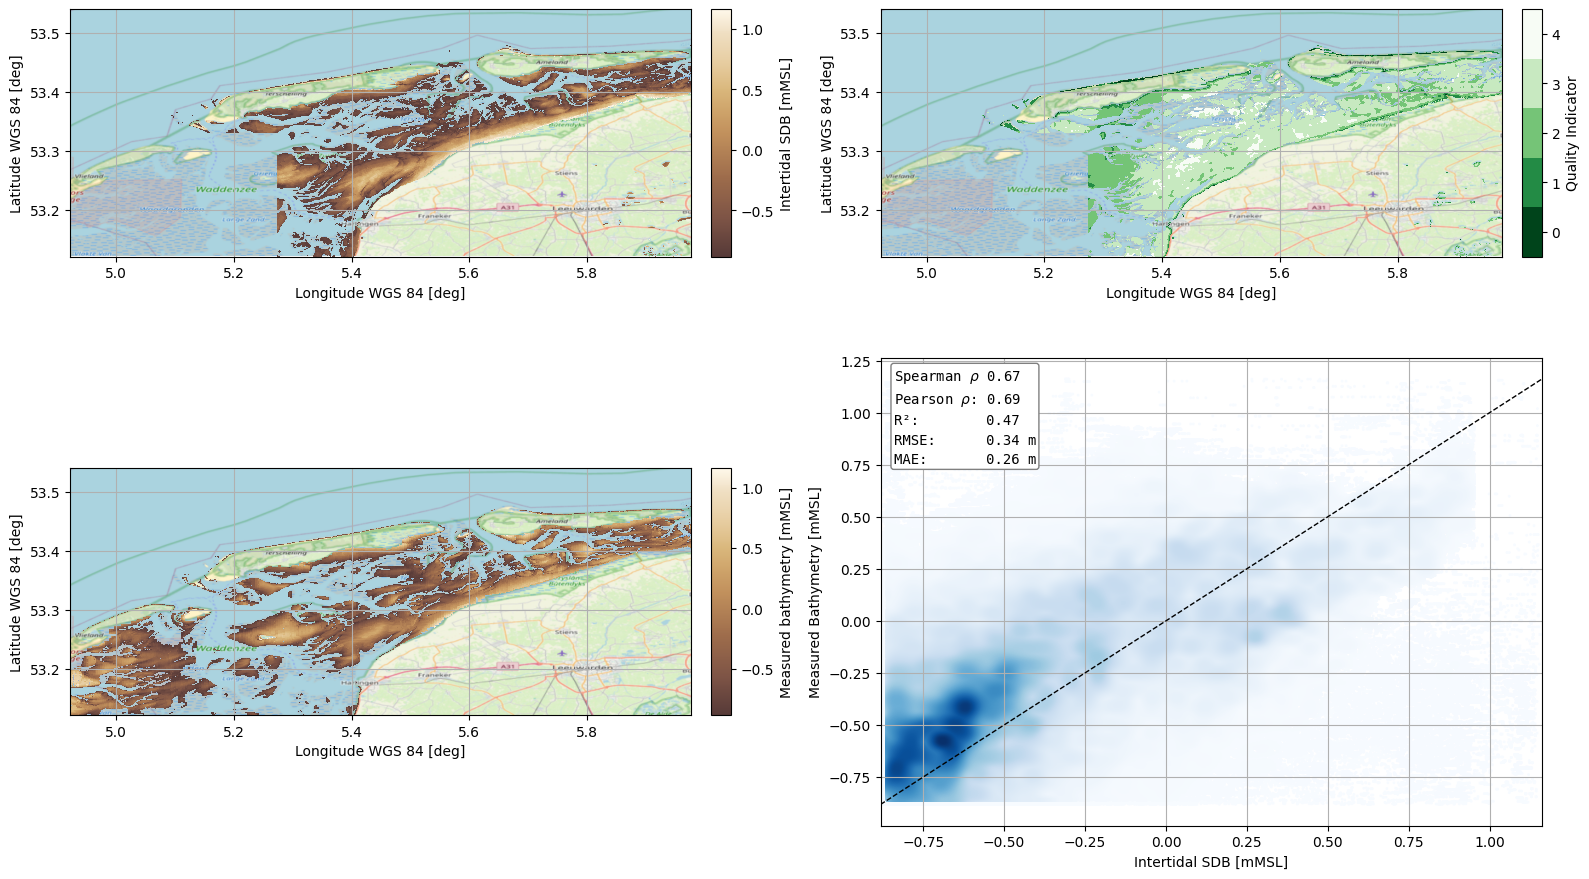

Processing date range: 2020-01-01_2021-01-01_10m


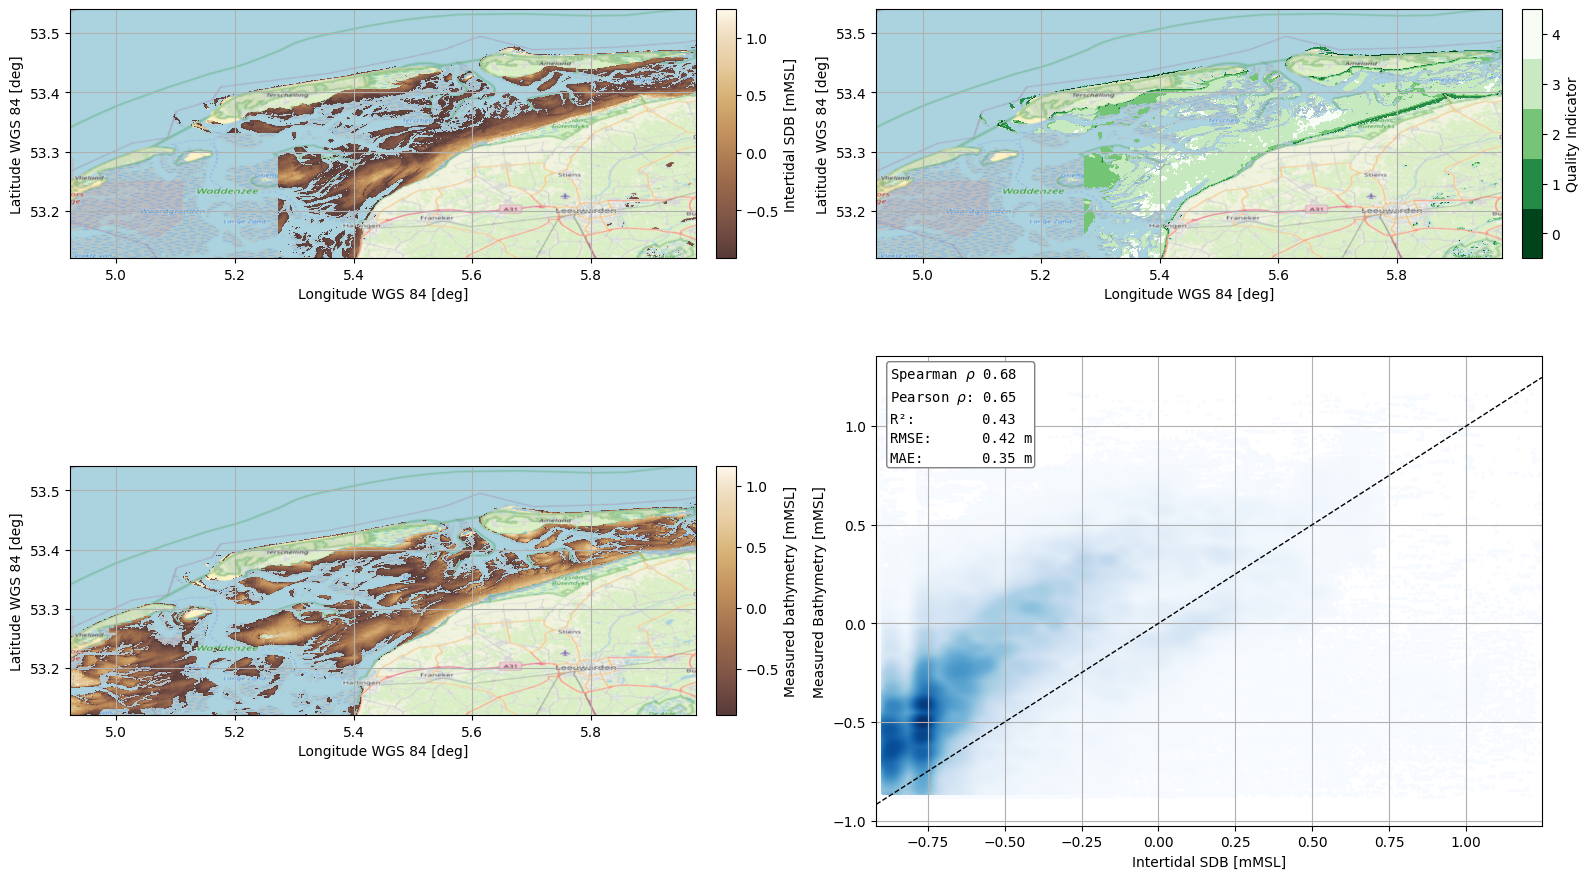

Processing date range: 2021-01-01_2022-01-01_10m


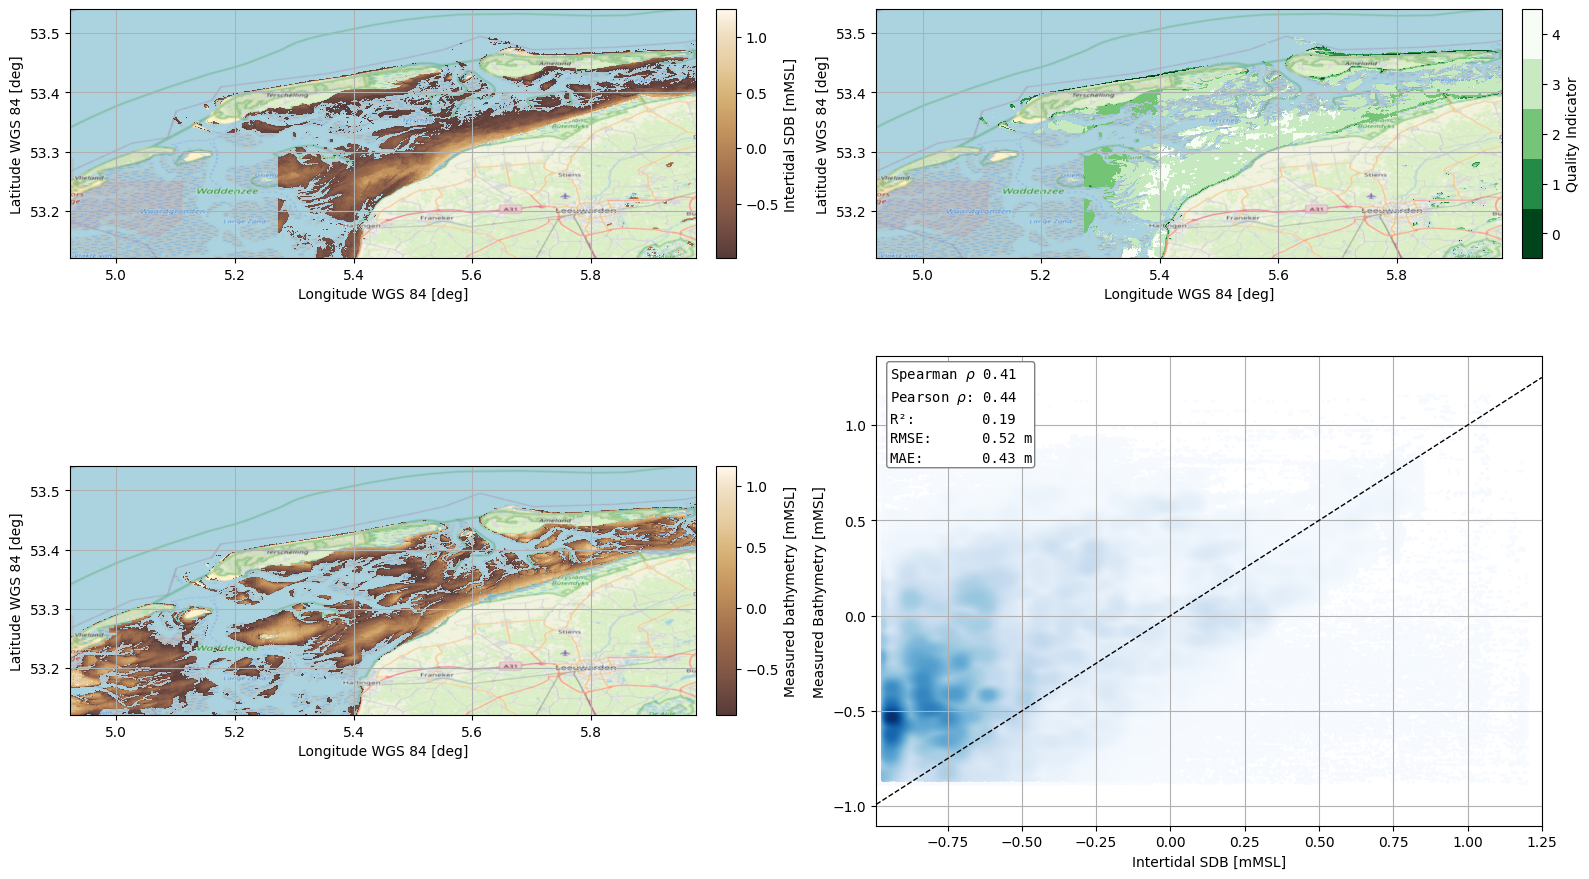

Processing date range: 2022-01-01_2023-01-01_10m


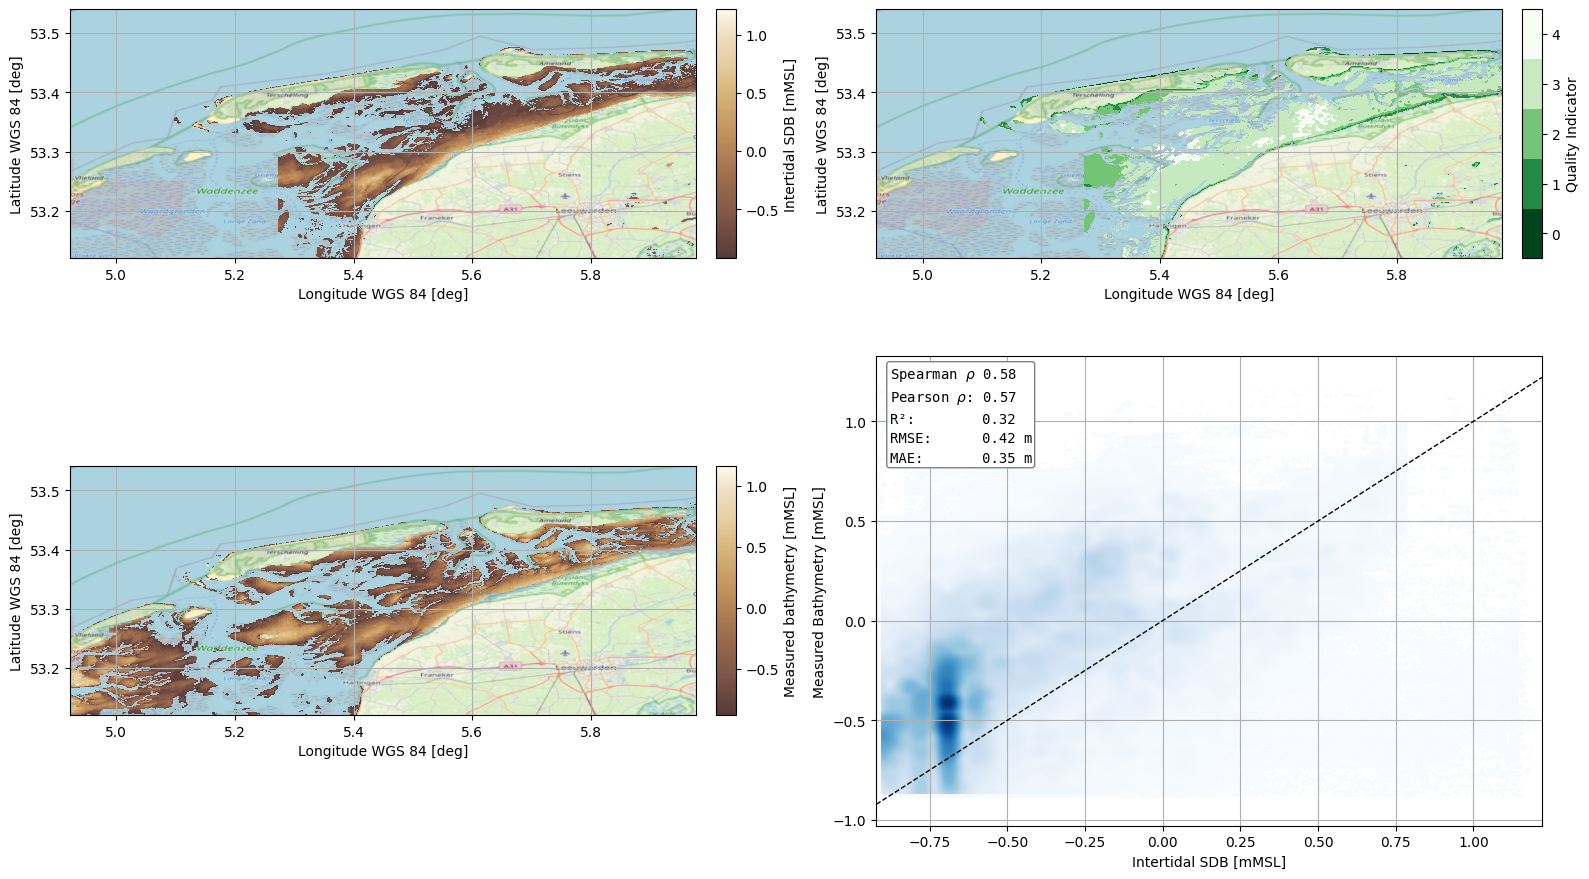

Processing date range: 2023-01-01_2024-01-01_10m


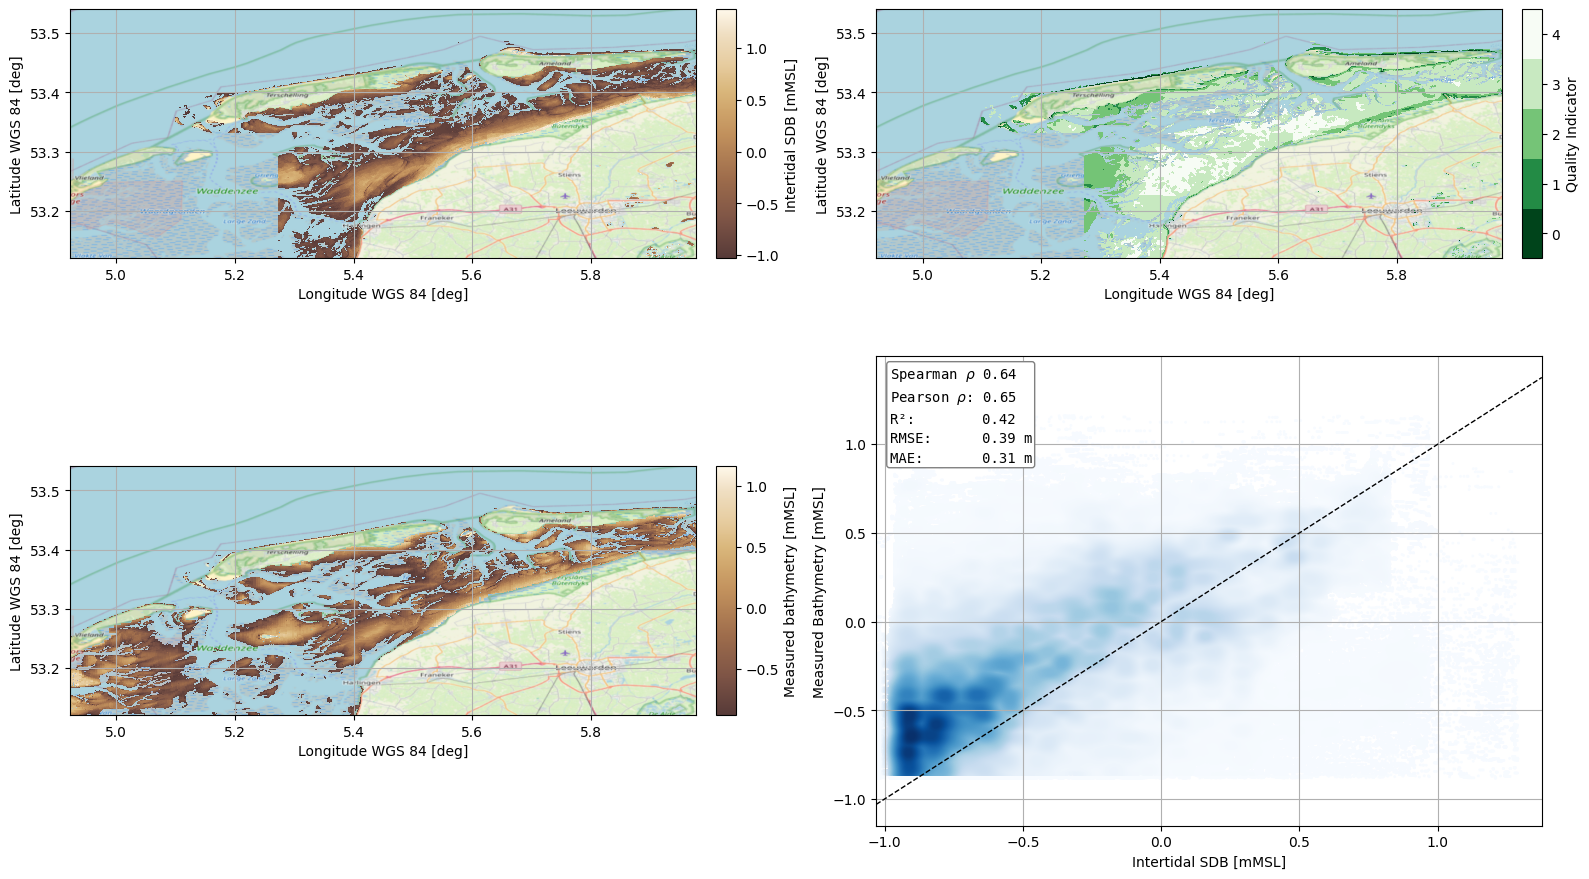

In [13]:
import scipy
def calculate_statistics(x, y):
    # Remove nans
    idx_nans = np.logical_or(np.isnan(x), np.isnan(y))
    x = x[~idx_nans]
    y = y[~idx_nans]

    # Get statistics
    stats = {}
    if len(x) > 2:
        stats['spearman_r'] = scipy.stats.spearmanr(x, y).correlation # Spearman rank-order correlation coefficient (1 = perfect correlation)
        stats['pearson_r'] = scipy.stats.pearsonr(x, y)[0]            # Pearson correlation coefficient (1 = perfect correlation)
        stats['r2'] = scipy.stats.linregress(x, y).rvalue**2          # Coefficient of determination (1 = perfect correlation)
        stats['rmse'] = np.sqrt(np.mean((x - y)**2))            # Root Mean Squared Error (lower is better)
        stats['mae'] = np.mean(np.abs(x - y))                   # Mean Absolute Error (lower is better)
    else:
        stats['spearman_r'] = np.nan
        stats['pearson_r'] = np.nan
        stats['r2'] = np.nan
        stats['rmse'] = np.nan
        stats['mae'] = np.nan

    return stats

from scipy.interpolate import interpn
def density_scatter(x, y, ax, sort = True, bins = 20, **kwargs):
    # Remove nans
    idx_nans = np.logical_or(np.isnan(x), np.isnan(y))
    x = x[~idx_nans]
    y = y[~idx_nans]
    
    data , x_e, y_e = np.histogram2d( x, y, bins = bins, density = True )
    z = interpn( ( 0.5*(x_e[1:] + x_e[:-1]) , 0.5*(y_e[1:]+y_e[:-1]) ) , data , np.vstack([x, y]).T , method = "splinef2d", bounds_error = False)

    #To be sure to plot all data
    z[np.where(np.isnan(z))] = 0.0

    # Sort the points by density, so that the densest points are plotted last
    if sort :
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]

    # Create a scatter plot
    ax.scatter(x, y, c=z, **kwargs)

    return ax

def plot_statistics(stats, ax):
    text = '\n'.join(['Spearman $\\rho$ {:.2f}'.format(stats['spearman_r']),
                        'Pearson $\\rho$: {:.2f}'.format(stats['pearson_r']),
                        'R²:        {:.2f}'.format(stats['r2']),
                        'RMSE:      {:.2f} m'.format(stats['rmse']),
                        'MAE:       {:.2f} m'.format(stats['mae'])])
    ax.text(0.02, 0.978, text, color='black', transform=ax.transAxes, verticalalignment='top', family='monospace', linespacing=1.5,
            bbox=dict(facecolor='white', edgecolor='grey', boxstyle='round,pad=0.2'))

def plot_data(ds_sdb, ds_insitu, extent_style, vmin=None, vmax=None):
    # Calculate statistics
    x = ds_sdb.isel(band=0).values.flatten()
    y = ds_insitu.values.flatten()
    stats = calculate_statistics(x, y)
    
    # Get vmin and vmax
    if vmin is None:
        vmin = ds_sdb.isel(band=0).min().values
    if vmax is None:
        vmax = ds_sdb.isel(band=0).max().values

    # Create figure and axis
    fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
    axs = axs.flatten()

    # Plot SDB data
    rpc.imshow(ds_sdb.isel(band=0), ax=axs[0], data_style='default', cbar_kwargs={'label': 'Intertidal SDB [mMSL]'}, cmap=cmaps.brown_sable, vmin=vmin, vmax=vmax)

    # Plot SDB quality indicator
    import matplotlib as mpl
    cmap = mpl.colors.ListedColormap(mpl.colormaps['Greens_r'](np.linspace(0, 1, 5)))
    rpc.imshow(ds_sdb.isel(band=1), ax=axs[1], data_style='default', cbar_kwargs={'label': 'Quality Indicator'}, vmin=-0.5, vmax=4.5, cmap=cmap)

    # Plot insitu data
    rpc.imshow(ds_insitu, ax=axs[2], data_style='default', cbar_kwargs={'label': 'Measured bathymetry [mMSL]'}, cmap=cmaps.brown_sable)

    # Plot basemaps
    for ax in axs[0:3]:
        rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style=extent_style)
    
    # Plot statistics
    x = ds_sdb.isel(band=0).values.flatten()
    y = ds_insitu.values.flatten()
    density_scatter(x, y, axs[3], sort=True, bins=50, cmap='Blues', s=1)
    plot_statistics(stats, axs[3])
    axs[3].plot([vmin, vmax], [vmin, vmax], color='black', linestyle='--', linewidth=1)
    axs[3].set_xlabel('Intertidal SDB [mMSL]')
    axs[3].set_ylabel('Measured Bathymetry [mMSL]')
    axs[3].set_xlim(vmin, vmax)
    axs[3].grid()

    # Show figure
    rpc.show(fig=fig)


for date_range in date_ranges:
    print(f"Processing date range: {date_range}")
    plot_data(ds_sdb_dwz_dict[date_range], ds_insitu_dwz, extent_style='dutch waddenzee')